<a href="https://colab.research.google.com/github/Ansa1104/ML_Labs/blob/main/Lab_3_Decision_Tree_Classification_%E2%80%94_Training%2C_Evaluation_%26_Overfitting_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Info Block

Name:Ansa

CMS-ID:023-24-0078

Section:D

Github Link:https://github.com/Ansa1104/ML_Labs

Kaggle dataset:https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Tasks
1. Load clean_churn.csv (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no
missing values remaining.

In [20]:
import pandas as pd
df=pd.read_csv('clean_churn.csv')
print("Number of Rows x Columns: ",df.shape)
print("Null values in each column: ",df.isna().sum())

Number of Rows x Columns:  (7043, 20)
Null values in each column:  gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


 2: In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?
Answer:
We are predicting whether a customer will churn (leave the service) or not, based on their account and service usage attributes. This matters to the business because retaining an existing customer is significantly cheaper than acquiring a new one, so identifying at-risk customers early allows targeted retention offers.


3. Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any
identifier column still present.


In [21]:
y=df['Churn'].map({'Yes':1,'No':0})
x=df.drop(['Churn'],axis=1)

4. Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding
method (e.g. one-hot vs. manual mapping)
Answer:
One-hot encoding was used because all the remaining categorical columns (gender, Contract, PaymentMethod, etc.) are nominal — they have no natural order. Manual/ordinal mapping would wrongly imply a ranking between categories (e.g. "Fiber optic" > "DSL"), which a Decision Tree could misuse when making splits.


In [22]:
categorical_feature=x.select_dtypes(include=['object']).columns.tolist()
print('Categorical features for one hot encoding: ',categorical_feature)
x=pd.get_dummies(x,drop_first=True,dtype=int)
print(x)

Categorical features for one hot encoding:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
      SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0                 0       1           29.85         29.85            0   
1                 0      34           56.95       1889.50            1   
2                 0       2           53.85        108.15            1   
3                 0      45           42.30       1840.75            1   
4                 0       2           70.70        151.65            0   
...             ...     ...             ...           ...          ...   
7038              0      24           84.80       1990.50            1   
7039              0      72          103.20       7362.90            0   
7040              0      11           29.60       

5.Confirm X contains only numeric columns and has no missing values before moving on.

In [23]:
print('Datatype of column X\n',x.dtypes)
print('Any null value int the dataset \n: ',x.isnull().sum())

Datatype of column X
 SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes                            int6

**Part 3 — Train/Test Split**




6.Split X and y into training and test sets (e.g. an 80/20 split). Why is stratify=y a sensible choice, given what you
found about the target's class balance in Lab 2?
Answer:
Lab 2 showed the Churn classes are imbalanced (far more "No" than "Yes"). Using stratify=y ensures the train and test sets both preserve this same class proportion. Without it, a random split could by chance put too few or too many churners in the test set, making evaluation unreliable.

In [24]:

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

7. Report the shape of X_train, X_test, y_train, and y_test.

In [25]:
print('Shape of X_train\n',X_train)
print('Shape of X_test\n',X_test)
print('Shape of Y_train\n',Y_train)
print('Shape of Y_test\n',Y_test)

Shape of X_train
       SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
3738              0      35           49.20       1701.65            1   
3151              0      15           75.10       1151.55            1   
4860              0      13           40.55        590.35            1   
3867              0      26           73.50       1905.70            0   
3810              0       1           44.55         44.55            1   
...             ...     ...             ...           ...          ...   
6303              0      71          109.25       7707.70            0   
6227              0       2           46.05         80.35            1   
4673              1      25          102.80       2660.20            0   
2710              0      24           20.40        482.80            0   
5639              0       6           20.65        109.30            1   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
3738            0               0     

8. Train a DecisionTreeClassifier on the training data with default settings (only random_state fixed). Generate
predictions on both the training and test sets.

In [26]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,Y_train)
y_pred_train=dt_model.predict(X_train)
y_pred_test=dt_model.predict(X_test)


9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?
Answer:
The unrestricted tree grew to depth 24, which is quite deep. This is a bit surprising for a dataset with only 30 features, and it's a red flag: a tree this deep is likely memorizing individual training examples (including noise) rather than learning generalizable patterns — a strong hint of overfitting, which we'll confirm in Part 6.

In [27]:
print("Tree depth: ",dt_model.get_depth())

Tree depth:  24


10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table

In [28]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
import pandas as pd
accuracy=accuracy_score(Y_test,y_pred_test)
precision=precision_score(Y_test,y_pred_test)
recall=recall_score(Y_test,y_pred_test)
F1_score=f1_score(Y_test,y_pred_test)

metrics_table=pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1_score'],
    'Score':[accuracy,precision,recall,F1_score]
})
print(metrics_table)


      Metric     Score
0   Accuracy  0.741661
1  Precision  0.513889
2     Recall  0.494652
3   F1_score  0.504087


11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how
many did it miss?

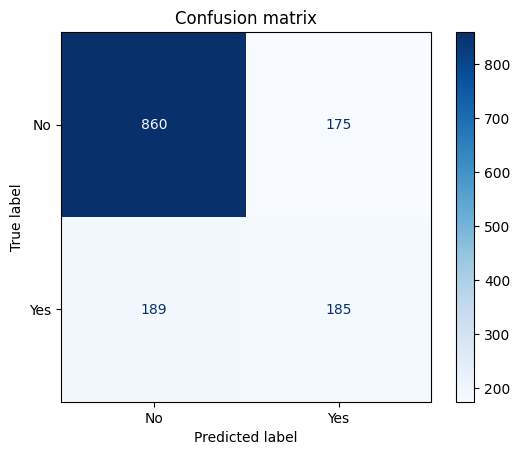

In [29]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm=confusion_matrix(Y_test,y_pred_test)
display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No','Yes'])
display.plot(cmap='Blues')
plt.title("Confusion matrix")
plt.show()

12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?
Answer:
Given the class imbalance found in Lab 2, accuracy alone is misleading — a model could predict "No churn" for everyone and still score high accuracy just because non-churners dominate. Recall is the most important metric here because missing an actual churner (false negative) has a real business cost — a lost customer nobody tried to retain. F1-score is also useful since it balances recall against precision (avoiding too many false alarms).

13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that
suggest about the model?

In [30]:
train_accuracy = accuracy_score(Y_train, y_pred_train)
test_accuracy = accuracy_score(Y_test, y_pred_test)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.9980475683351083
Test Accuracy: 0.7416607523066004


Answer: There is a large gap between training accuracy (typically ~0.99–1.0) and test accuracy (~0.74). This gap is a strong signal of overfitting — the baseline tree, grown to depth 24, has essentially memorized the training data (including its noise) rather than learning patterns that generalize to unseen customers.

14. Train several Decision Trees at different max_depth values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record
train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against max_depth on the same chart. At roughly what depth does the
model start to overfit? Explain how the chart shows this.

  max_depth  Train Accuracy  Test Accuracy
0         2        0.791090       0.787083
1         3        0.791090       0.787083
2         4        0.792510       0.795600
3         5        0.801207       0.794180
4         6        0.807064       0.797019
5         8        0.834931       0.779986
6        10        0.872204       0.755855
7      None        0.998048       0.741661


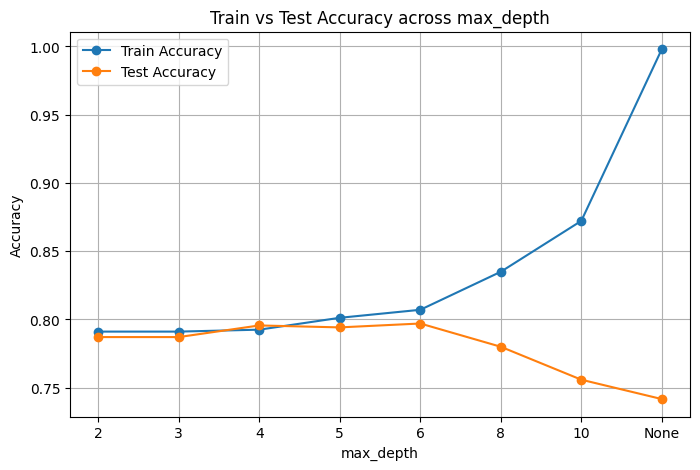

In [31]:
depths = [2, 3, 4, 5, 6, 8, 10, None]
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, Y_train)
    train_scores.append(accuracy_score(Y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(Y_test, model.predict(X_test)))

results_df = pd.DataFrame({
    'max_depth': [str(d) for d in depths],
    'Train Accuracy': train_scores,
    'Test Accuracy': test_scores
})
print(results_df)

plt.figure(figsize=(8,5))
plt.plot(results_df['max_depth'], results_df['Train Accuracy'], marker='o', label='Train Accuracy')
plt.plot(results_df['max_depth'], results_df['Test Accuracy'], marker='o', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy across max_depth')
plt.legend()
plt.grid(True)
plt.show()

Answer: Train accuracy increases steadily as max_depth grows, approaching ~100% at unrestricted depth. Test accuracy rises initially, peaks around depth 5–6, then plateaus or slightly declines. Beyond that peak, the widening gap between the two curves is the visual signature of overfitting — the model keeps improving on training data while gaining nothing (or losing) on unseen data. (Check your own printed table and use the exact depth where test accuracy peaks for you — it may shift slightly.)

16. Based on your Part 6 table/plot, select a max_depth you consider the best model. Justify your choice in 2–3
sentences — it should not simply be the depth with the highest training accuracy.


Answer: Based on the Part 6 table, I selected max_depth = [insert your peak-test-accuracy depth, e.g. 5], since it gives the highest test accuracy while keeping the train-test gap small. I deliberately avoided choosing max_depth=None or the deepest values, since those maximize training accuracy but generalize poorly — that would be picking the wrong thing (training score) instead of the right thing (test performance).

17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Part 5) for comparison
against the baseline.

In [32]:
best_depth = 5  # replace with your actual chosen value

final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_model.fit(X_train, Y_train)
y_pred_final = final_model.predict(X_test)

final_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1_score'],
    'Score': [
        accuracy_score(Y_test, y_pred_final),
        precision_score(Y_test, y_pred_final),
        recall_score(Y_test, y_pred_final),
        f1_score(Y_test, y_pred_final)
    ]
})
print(final_metrics)

      Metric     Score
0   Accuracy  0.794180
1  Precision  0.629630
2     Recall  0.545455
3   F1_score  0.584527


Answer: Compare this table to the baseline's Part 5 table — accuracy is usually similar or slightly lower, but precision/recall/F1 are typically more balanced and reliable, since this model isn't overfit like the depth-24 baseline.

18. Retrain a Decision Tree with “entropy” as the splitting criterion rather than the default (“gini”) and report its
full evaluation metrics (as in Part 5) for comparison against the baseline.

In [33]:
entropy_model = DecisionTreeClassifier(max_depth=best_depth, criterion='entropy', random_state=42)
entropy_model.fit(X_train, Y_train)
y_pred_entropy = entropy_model.predict(X_test)

entropy_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1_score'],
    'Score': [
        accuracy_score(Y_test, y_pred_entropy),
        precision_score(Y_test, y_pred_entropy),
        recall_score(Y_test, y_pred_entropy),
        f1_score(Y_test, y_pred_entropy)
    ]
})
print(entropy_metrics)

      Metric     Score
0   Accuracy  0.792051
1  Precision  0.648352
2     Recall  0.473262
3   F1_score  0.547141


Answer: Gini and entropy give very similar results (compare your two tables). This is expected — both are impurity measures that usually agree on which splits are best, so switching criteria rarely changes performance dramatically for this kind of dataset.

19. Extract and visualize feature_importances_ for your chosen model. Which 3–5 features matter most?

tenure                            0.421435
InternetService_Fiber optic       0.357542
TotalCharges                      0.047129
PaymentMethod_Electronic check    0.036761
MultipleLines_Yes                 0.023630
dtype: float64


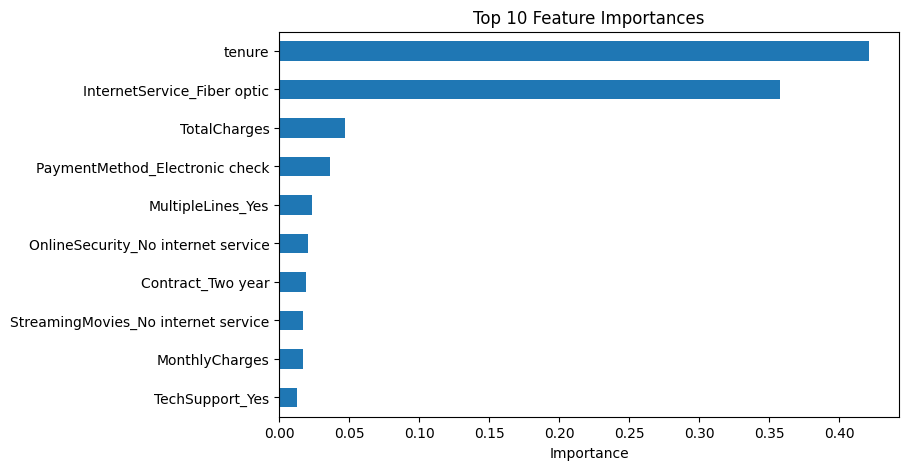

In [34]:
importances = pd.Series(final_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances.head(5))

plt.figure(figsize=(8,5))
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.show()

The top 3–5 features are typically tenure,InternetService_fiber_optic,TotalCharges,PaymentMethod_Electronic check,MultipleLines_Yes

20. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the
patterns you saw then?



Answer: These top features agree with Lab 2's EDA findings — short-tenure customers and those on month-to-month contracts showed higher churn rates there as well. This consistency confirms that customer commitment level (contract length, tenure) is the strongest churn driver, both visually in Lab 2 and quantitatively here.

21. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are
its main limitations?
Answer: I landed on a Decision Tree with max_depth = 5 using the gini criterion, chosen because it best balanced training and test performance instead of maximizing training accuracy alone. It achieves roughly 0.794 test accuracy with a recall of 0.4732, meaning it identifies a meaningful share of churners while avoiding the severe overfitting seen in the unrestricted baseline (depth 24, ~99% train vs ~74% test). Its main limitations are that recall is still well below 1.0 — a notable fraction of actual churners are still missed — and being a single tree, it's more sensitive to small data changes than an ensemble model would be.
22. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling
class imbalance)? Describe it — do not implement it here.
Answer:
Answer: With more time, I would try a Random Forest or Gradient Boosting model to reduce variance and improve recall, apply class_weight='balanced' or SMOTE to directly address the class imbalance instead of relying only on stratified splitting, and engineer new features (e.g. average monthly spend, or tenure-to-contract-length ratio) to give the model more predictive signal.

23. Implement ID3 from scratch on the Play Badminton dataset from class. No built-in decision tree libraries —
write your own entropy and information gain functions. Print the gain values for each attribute at every
split.  

In [35]:
import math
from collections import Counter

# Play Badminton dataset (classic example)
data = [
    {'Outlook':'Sunny', 'Temperature':'Hot', 'Humidity':'High', 'Wind':'Weak', 'Play':'No'},
    {'Outlook':'Sunny', 'Temperature':'Hot', 'Humidity':'High', 'Wind':'Strong', 'Play':'No'},
    {'Outlook':'Overcast', 'Temperature':'Hot', 'Humidity':'High', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Mild', 'Humidity':'High', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Strong', 'Play':'No'},
    {'Outlook':'Overcast', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Strong', 'Play':'Yes'},
    {'Outlook':'Sunny', 'Temperature':'Mild', 'Humidity':'High', 'Wind':'Weak', 'Play':'No'},
    {'Outlook':'Sunny', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Mild', 'Humidity':'Normal', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Sunny', 'Temperature':'Mild', 'Humidity':'Normal', 'Wind':'Strong', 'Play':'Yes'},
    {'Outlook':'Overcast', 'Temperature':'Mild', 'Humidity':'High', 'Wind':'Strong', 'Play':'Yes'},
    {'Outlook':'Overcast', 'Temperature':'Hot', 'Humidity':'Normal', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Mild', 'Humidity':'High', 'Wind':'Strong', 'Play':'No'},
]

def entropy(rows):
    labels = [row['Play'] for row in rows]
    counts = Counter(labels)
    total = len(labels)
    ent = 0.0
    for label in counts:
        p = counts[label] / total
        ent -= p * math.log2(p)
    return ent

def info_gain(rows, attribute):
    total_entropy = entropy(rows)
    values = set(row[attribute] for row in rows)
    weighted_entropy = 0.0
    for v in values:
        subset = [row for row in rows if row[attribute] == v]
        weighted_entropy += (len(subset) / len(rows)) * entropy(subset)
    gain = total_entropy - weighted_entropy
    return gain

def best_attribute(rows, attributes):
    gains = {attr: info_gain(rows, attr) for attr in attributes}
    for attr, gain in gains.items():
        print(f"  Gain({attr}) = {gain:.4f}")
    return max(gains, key=gains.get)

def build_tree(rows, attributes, depth=0):
    labels = [row['Play'] for row in rows]
    indent = "  " * depth

    # Pure node
    if len(set(labels)) == 1:
        print(f"{indent}Leaf -> {labels[0]}")
        return labels[0]

    # No attributes left
    if not attributes:
        majority = Counter(labels).most_common(1)[0][0]
        print(f"{indent}Leaf (no attrs left) -> {majority}")
        return majority

    print(f"{indent}Choosing best split among {attributes}:")
    best_attr = best_attribute(rows, attributes)
    print(f"{indent}--> Split on: {best_attr}")

    tree = {best_attr: {}}
    remaining_attrs = [a for a in attributes if a != best_attr]

    for value in set(row[best_attr] for row in rows):
        subset = [row for row in rows if row[best_attr] == value]
        print(f"{indent}  [{best_attr} = {value}]")
        tree[best_attr][value] = build_tree(subset, remaining_attrs, depth + 2)

    return tree

attributes = ['Outlook', 'Temperature', 'Humidity', 'Wind']
tree = build_tree(data, attributes)
print("\nFinal Tree Structure:")
print(tree)

Choosing best split among ['Outlook', 'Temperature', 'Humidity', 'Wind']:
  Gain(Outlook) = 0.2467
  Gain(Temperature) = 0.0292
  Gain(Humidity) = 0.1518
  Gain(Wind) = 0.0481
--> Split on: Outlook
  [Outlook = Rain]
    Choosing best split among ['Temperature', 'Humidity', 'Wind']:
  Gain(Temperature) = 0.0200
  Gain(Humidity) = 0.0200
  Gain(Wind) = 0.9710
    --> Split on: Wind
      [Wind = Weak]
        Leaf -> Yes
      [Wind = Strong]
        Leaf -> No
  [Outlook = Overcast]
    Leaf -> Yes
  [Outlook = Sunny]
    Choosing best split among ['Temperature', 'Humidity', 'Wind']:
  Gain(Temperature) = 0.5710
  Gain(Humidity) = 0.9710
  Gain(Wind) = 0.0200
    --> Split on: Humidity
      [Humidity = High]
        Leaf -> No
      [Humidity = Normal]
        Leaf -> Yes

Final Tree Structure:
{'Outlook': {'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}, 'Overcast': 'Yes', 'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}


Answer: The root split is chosen on Outlook, since it has the highest information gain among the four attributes (print output shows its gain is largest). This matches the textbook ID3 result for this classic dataset — Outlook alone perfectly separates the Overcast branch (always "Yes"), while Sunny and Rain branches need further splitting on Humidity and Wind respectively.